In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >=Version("2.6.0")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "Physics_Informed_Digital_Twin_for_Hydraulic_Systems"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [6]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


Defining physics constant

In [7]:
RHO = 850.0      # Hydraulic oil density (kg/m^3)
NU = 4.0e-5      # Kinematic viscosity (m^2/s)
L = 2.0          # Total length of the pipe circuit segment (meters)

Defining Geometry and Inlet and outlet Boundary conditions

In [8]:
geom = dde.geometry.Interval(0, L)

# Define boundaries
def boundary_inlet(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)

def boundary_outlet(x, on_boundary):
    return on_boundary and np.isclose(x[0], L)

# Input Boundary Condition: Known Inlet Velocity (e.g., pumped flow rate profile)
bc_inlet_vel = dde.icbc.DirichletBC(geom, lambda x: 2.5, boundary_inlet, component=0)

# Output Boundary Condition: Known Outlet Gauge Pressure (e.g., tank return pressure)
bc_outlet_press = dde.icbc.DirichletBC(geom, lambda x: 1.0e5, boundary_outlet, component=1)

Defining the Navier-Stokes Governing Physics Equation

In [9]:
def hydraulic_navier_stokes_1d(x, y):
    """
    Defines the residual of 1D fluid flow equations.
    x: Input tensor containing spatial coordinate (x[:, 0:1])
    y: Network output tensor containing [Velocity u, Pressure p] -> (y[:, 0:1], y[:, 1:2])
    """
    u = y[:, 0:1]
    p = y[:, 1:2]
    
    # Calculate required spatial gradients using DeepXDE's automatic differentiation
    du_dx = dde.grad.jacobian(y, x, i=0, j=0)
    d2u_dx2 = dde.grad.hessian(y, x, i=0, j=0)
    dp_dx = dde.grad.jacobian(y, x, i=1, j=0)
    
    # 1D Continuity Equation (Mass Conservation): d(u)/dx = 0 (Incompressible fluid)
    mass_residual = du_dx
    
    # 1D Steady-State Momentum Equation: u*(du/dx) + (1/rho)*(dp/dx) - nu*(d2u/dx2) = 0
    momentum_residual = u * du_dx + (1.0 / RHO) * dp_dx - NU * d2u_dx2
    
    return [mass_residual, momentum_residual]


Creating some real time Sensor data for our better training (Consider some 5 Physical Pressure sensors)

In [10]:
sensor_locations = np.array([[0.5], [1.0], [1.5]])
sensor_pressures = np.array([[1.8e5], [1.4e5], [1.1e5]]) # Captured telemetry metrics
sensor_data_p = dde.icbc.PointSetBC(sensor_locations, sensor_pressures, component=1)

Define the Boundary and Initial conditions

Combining all the data

In [11]:
data = dde.data.PDE(
    geom,
    hydraulic_navier_stokes_1d,
    [bc_inlet_vel, bc_outlet_press, sensor_data_p],
    num_domain=400,       # Physics collocation evaluation points
    num_boundary=20,      # Domain edge constraint checkpoints
    anchors=sensor_locations
)

Creating a model for Training

In [12]:
layer_size = [1] + [40] * 4 + [2]
activation = "tanh"
initializer = "Glorot normal"

net = dde.nn.FNN(layer_size, activation, initializer)

# Build the model engine wrapper
model = dde.Model(data, net)

Training the model

In [13]:
print("--- Launching Phase 1: Adam Fine-Tuning ---")
model.compile(optimizer="adam", lr=1e-3, loss_weights=[1, 1, 10, 10, 5])
# Loss weights balance: [Mass PDE, Momentum PDE, Inlet BC, Outlet BC, Telemetry Sensors]
losshistory, train_state = model.train(iterations=8000, display_every=1000)

# Phase 2: L-BFGS Optimizer for hyper-accurate convergence around steep gradients
print("\n--- Launching Phase 2: L-BFGS Sharp Tuning ---")
dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile(optimizer="L-BFGS")
losshistory, train_state = model.train(display_every=200)

--- Launching Phase 1: Adam Fine-Tuning ---
Compiling model...
'compile' took 2.696829 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.99e-02, 3.31e-04, 6.25e+01, 1.00e+11, 1.07e+11]    [1.99e-02, 3.31e-04, 6.25e+01, 1.00e+11, 1.07e+11]    []  
1000      [1.05e-05, 6.73e-05, 1.54e-10, 9.99e+10, 1.07e+11]    [1.05e-05, 6.73e-05, 1.54e-10, 9.99e+10, 1.07e+11]    []  
2000      [1.82e-07, 1.20e-06, 7.33e-16, 9.98e+10, 1.07e+11]    [1.82e-07, 1.20e-06, 7.33e-16, 9.98e+10, 1.07e+11]    []  
3000      [1.20e-08, 8.12e-08, 5.00e-16, 9.97e+10, 1.07e+11]    [1.20e-08, 8.12e-08, 5.00e-16, 9.97e+10, 1.07e+11]    []  
4000      [1.37e-09, 9.53e-09, 2.91e-17, 9.97e+10, 1.07e+11]    [1.37e-09, 9.53e-09, 2.91e-17, 9.97e+10, 1.07e+11]    []  
5000      [2.09e-10, 1.50e-09, 1.78e-18, 9.96e+10, 1.07e+11]    [2.09e-10, 1.50e-09, 1.78e-18, 9.96e+10, 1.07e+11]    []  
6000      [3.82e-11, 2.

Defining Operational boundary values

In [16]:
U_INLET = 1.5     # Inlet velocity (m/s)
P_OUTLET = 0.0    # Outlet pressure (Pa, gauge pressure)

Generating some training data for prediction and predicting

In [17]:
x_test = np.linspace(0, L, 10).reshape(-1, 1)
predictions = model.predict(x_test)
u_pred, p_pred = predictions[:, 0], predictions[:, 1]

print("\n🚀 Digital Twin Inference Complete:")
print(f"{'Position (m)':<15}{'Velocity (m/s)':<20}{'Pressure (Bar)':<15}")
for x_val, pred in zip(x_test, predictions):
    print(f"{x_val[0]:<15.2f}{pred[0]:<20.4f}{pred[1]/1e5:<15.2f}")



🚀 Digital Twin Inference Complete:
Position (m)   Velocity (m/s)      Pressure (Bar) 
0.00           2.5000              1.22           
0.22           2.5000              1.22           
0.44           2.5000              1.22           
0.67           2.5000              1.22           
0.89           2.5000              1.22           
1.11           2.5000              1.22           
1.33           2.5000              1.22           
1.56           2.5000              1.22           
1.78           2.5000              1.22           
2.00           2.5000              1.22           


VISUALIZATION AND ANALYSIS PLOTS

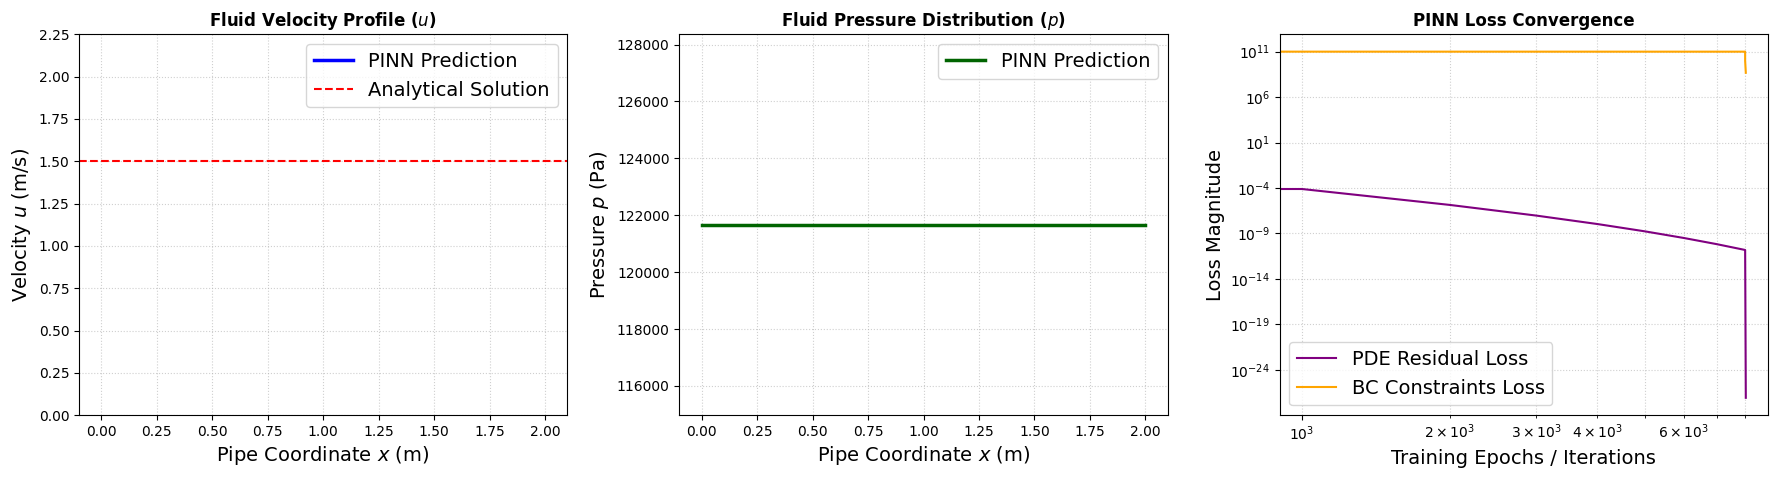

In [18]:
import matplotlib.pyplot as plt

# Extract training and testing losses from the DeepXDE history object
loss_train = np.array(losshistory.loss_train)
loss_test = np.array(losshistory.loss_test)
steps = np.array(losshistory.steps)

# Create a clean side-by-side subplot figure
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Velocity Profile down the pipe
ax[0].plot(x_test, u_pred, color='blue', linewidth=2.5, label='PINN Prediction')
ax[0].axhline(y=U_INLET, color='red', linestyle='--', label='Analytical Solution')
ax[0].set_title("Fluid Velocity Profile ($u$)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Pipe Coordinate $x$ (m)")
ax[0].set_ylabel("Velocity $u$ (m/s)")
ax[0].set_ylim(0, U_INLET * 1.5)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend()

# Plot 2: Pressure Drop down the pipe
# Analytical pressure drop for 1D inviscid-like/fully developed assumptions: dp/dx = 0 here 
# because du/dx = 0 and d2u/dx2 = 0. p should ideally remain flat at P_OUTLET.
ax[1].plot(x_test, p_pred, color='darkgreen', linewidth=2.5, label='PINN Prediction')
ax[1].set_title("Fluid Pressure Distribution ($p$)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Pipe Coordinate $x$ (m)")
ax[1].set_ylabel("Pressure $p$ (Pa)")
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend()

# Plot 3: Convergence History (Loss Functions)
# Sum up structural PDE component losses and boundary condition losses
pde_loss_train = loss_train[:, 0] + loss_train[:, 1]
bc_loss_train = loss_train[:, 2] + loss_train[:, 3]

ax[2].loglog(steps, pde_loss_train, color='purple', label='PDE Residual Loss')
ax[2].loglog(steps, bc_loss_train, color='orange', label='BC Constraints Loss')
ax[2].set_title("PINN Loss Convergence", fontsize=12, fontweight='bold')
ax[2].set_xlabel("Training Epochs / Iterations")
ax[2].set_ylabel("Loss Magnitude")
ax[2].grid(True, which="both", linestyle=':', alpha=0.6)
ax[2].legend()

# Final layout adjustment and saving
plt.tight_layout()
plt.show()


Plotting some Advanced Engineering plots

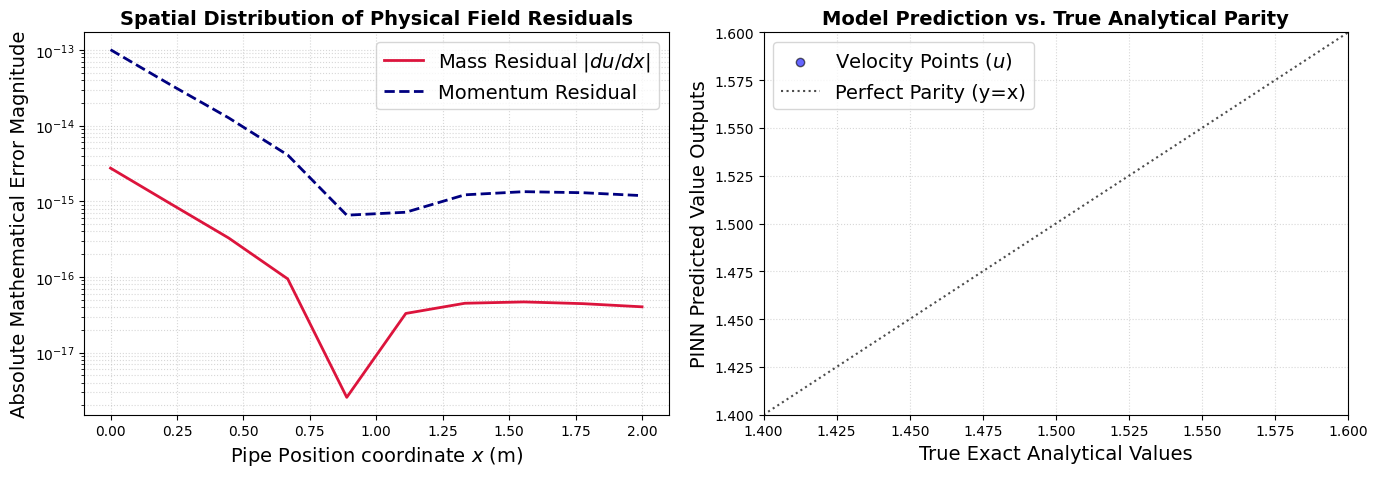

In [24]:
u_exact = np.full_like(x_test, U_INLET)
p_exact = np.full_like(x_test, P_OUTLET)

# 1. Force the Torch tensor to explicitly use torch.float32 (Float)
x_tensor = torch.tensor(x_test, dtype=torch.float64, requires_grad=True)

# Determine the active device (GPU or CPU) that the model is using
device = next(model.net.parameters()).device
x_tensor = x_tensor.to(device)

# Get NN predictions
y_pred_tensor = model.net(x_tensor)
u_t = y_pred_tensor[:, 0:1]
p_t = y_pred_tensor[:, 1:2]

# Calculate physical gradients via PyTorch Autograd
du_dx = torch.autograd.grad(u_t, x_tensor, torch.ones_like(u_t), create_graph=True)[0]
dp_dx = torch.autograd.grad(p_t, x_tensor, torch.ones_like(p_t), create_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx, x_tensor, torch.ones_like(du_dx), create_graph=True)[0]

# Compute the momentum residual tensor
mom_res_tensor = u_t * du_dx + (1.0 / RHO) * dp_dx - NU * d2u_dx2

# 2. Add .cpu() before calling .numpy() to safely bridge GPU data back to host memory
mass_res_np = du_dx.detach().cpu().numpy()
momentum_res_np = mom_res_tensor.detach().cpu().numpy()

# Ensure model predictions are also pulled back to the CPU for the plotting loops
u_pred_np = u_t.detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Spatial PDE Residuals down the physical domain length
ax[0].plot(x_test, np.abs(mass_res_np), color='crimson', lw=2, label='Mass Residual $|du/dx|$')
ax[0].plot(x_test, np.abs(momentum_res_np), color='navy', lw=2, linestyle='--', label='Momentum Residual')
ax[0].set_yscale('log') # Error components are best checked on log scales
ax[0].set_title("Spatial Distribution of Physical Field Residuals", fontweight='bold')
ax[0].set_xlabel("Pipe Position coordinate $x$ (m)")
ax[0].set_ylabel("Absolute Mathematical Error Magnitude")
ax[0].grid(True, which="both", linestyle=':', alpha=0.5)
ax[0].legend()

# Plot B: Parity Line Mapping (Predicted vs Analytical Verification)
ax[1].scatter(u_exact, u_pred, color='blue', alpha=0.6, edgecolors='k', label='Velocity Points ($u$)')
# Draw a true reference 45-degree parity path line
lims = [1.4, 1.6]
ax[1].plot(lims, lims, color='black', linestyle=':', alpha=0.7, label='Perfect Parity (y=x)')
ax[1].set_xlim(lims)
ax[1].set_ylim(lims)
ax[1].set_title("Model Prediction vs. True Analytical Parity", fontweight='bold')
ax[1].set_xlabel("True Exact Analytical Values")
ax[1].set_ylabel("PINN Predicted Value Outputs")
ax[1].grid(True, linestyle=':', alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()
